# Modelling and Evaluation

In this notebook, we train and evaluate regression models to predict a player's **performance score** (−1 to 12) from in-game statistics. Please go to `docs/3_modelling_and_evaluation.md` to get insights.


### Step 1: Import libraries and load training data


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

PROJECT_ROOT = Path().resolve().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

train_df = pd.read_csv(PROCESSED_DIR / "train" / "train.csv")

print("Train shape:", train_df.shape)
display(train_df.head())


Train shape: (1034, 22)


,game_id,episode,act,rank,date,agent,map,outcome,round_wins,round_losses,...,assists,kdr,avg_dmg_delta,headshot_pct,avg_dmg,acs,num_frag,role,win_loss_margin,performance
0,45,6,3,Gold 1,5/4/2023,Cypher,Bind,Win,13,9,...,10,1.153846,40,13,164,230,4,Sentinel,4,7
1,887,9,2,Ascendant 1,9/14/2024,Killjoy,Lotus,Win,13,11,...,2,1.866667,97,26,221,320,1,Sentinel,2,9
2,1230,7,3,Platinum 2,4/16/2023,Brimstone,Haven,Win,12,0,...,5,0.368421,24,97,145,131,7,Controller,12,7
3,1230,6,2,Gold 1,6/3/2023,Omen,Bind,Win,9,4,...,4,3.200000,0,96,51,131,1,Controller,5,5
4,944,9,2,Ascendant 2,10/9/2024,Cypher,Sunset,Loss,18,20,...,18,1.269231,43,26,180,266,2,Sentinel,-2,7


### Step 2: Feature selection and label encoding

**Features used:** `agent`, `role`, `avg_dmg_delta`, `win_loss_margin`, `kills`, `deaths`

Categorical columns (`agent`, `role`) are label-encoded. The fitted encoders are saved for use on the test set and during model export.


In [2]:
FEATURES = ['agent', 'role', 'avg_dmg_delta', 'win_loss_margin', 'kills', 'deaths']
TARGET   = 'performance'

X_raw = train_df[FEATURES].copy()
y     = train_df[TARGET].copy()

cat_cols = ['agent', 'role']
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_raw[col] = le.fit_transform(X_raw[col])
    label_encoders[col] = le

X = X_raw.copy()
print("Features used:", FEATURES)


Features used: ['agent', 'role', 'avg_dmg_delta', 'win_loss_margin', 'kills', 'deaths']


### Step 3: Train regression models

`performance` is an ordinal numeric score (−1 to 12), not a class label, regression is the appropriate framing. Four models are trained on the full training set and their training-set metrics are printed for a quick sanity check.


In [3]:
models = {
    "Random Forest":       RandomForestRegressor(
                               n_estimators=200, max_depth=15,
                               min_samples_leaf=4, min_samples_split=8,
                               random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingRegressor(
                               n_estimators=200, learning_rate=0.1,
                               max_depth=3, subsample=0.8,
                               random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=15, metric='euclidean'),
    "XGBoost":             XGBRegressor(
                               n_estimators=200, learning_rate=0.1,
                               max_depth=4, subsample=0.8,
                               colsample_bytree=0.8,
                               random_state=42, n_jobs=-1,
                               verbosity=0),
}

results = {}
for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X)
    mae  = mean_absolute_error(y, y_pred)
    rmse = mean_squared_error(y, y_pred) ** 0.5
    r2   = r2_score(y, y_pred)
    print(f"{name:25s}  Train MAE: {mae:.3f}  RMSE: {rmse:.3f}  R²: {r2:.3f}")
    results[name] = {"model": model, "y_pred": y_pred, "mae": mae, "rmse": rmse, "r2": r2}


Random Forest              Train MAE: 0.549  RMSE: 0.837  R²: 0.872
Gradient Boosting          Train MAE: 0.521  RMSE: 0.744  R²: 0.899
K-Nearest Neighbors        Train MAE: 0.819  RMSE: 1.210  R²: 0.732
XGBoost                    Train MAE: 0.404  RMSE: 0.565  R²: 0.942


### Step 4: Accuracy check: why accuracy alone falls short

We round predictions to the nearest integer and compute two metrics:
- **Exact accuracy** : rounded prediction matches actual value exactly
- **±1 tolerance** : prediction is within 1 point of actual

Both are shown here to demonstrate their limitation before switching to RMSE as the primary metric in Step 5.


#### Step 4A: Load and encode the test set


In [4]:
_test_df    = pd.read_csv(PROCESSED_DIR / "test" / "test.csv")
_X_test_raw = _test_df[FEATURES].copy()
_y_test     = _test_df[TARGET].copy()
for col in cat_cols:
    _X_test_raw[col] = label_encoders[col].transform(_X_test_raw[col])
_X_test = _X_test_raw.copy()


#### Step 4B: Compute exact and ±1 tolerance accuracy


In [5]:
print(f"{'Model':<25}  {'Train Exact':>12}  {'Train ±1':>10}  {'Test Exact':>11}  {'Test ±1':>9}")
print("-" * 74)
for name, res in results.items():
    # Round predictions and true values
    y_pred_rounded  = np.round(res["y_pred"]).astype(int) # Round predictions to nearest integer
    y_true_int      = y.values.astype(int)
    train_exact     = np.mean(y_pred_rounded == y_true_int) * 100 # Calculate exact accuracy on training set
    train_tol1      = np.mean(np.abs(y_pred_rounded - y_true_int) <= 1) * 100 # Calculate ±1 accuracy on training set

    # Evaluate on test set
    y_test_pred_acc = res["model"].predict(_X_test)
    y_test_rounded  = np.round(y_test_pred_acc).astype(int) # Round test predictions to nearest integer
    y_test_int      = _y_test.values.astype(int)
    test_exact      = np.mean(y_test_rounded == y_test_int) * 100 # Calculate exact accuracy on test set
    test_tol1       = np.mean(np.abs(y_test_rounded - y_test_int) <= 1) * 100 # Calculate ±1 accuracy on test set

    # Store results
    res["exact_acc"]      = train_exact
    res["tol1_acc"]       = train_tol1
    res["test_exact_acc"] = test_exact
    res["test_tol1_acc"]  = test_tol1

    display(f"{name:<25}  {train_exact:>11.1f}%  {train_tol1:>9.1f}%  {test_exact:>10.1f}%  {test_tol1:>8.1f}%")

print()
print("Exact accuracy is low because performance is a continuous ordinal score.")
print("A prediction of 4 vs actual 5 is 'wrong' despite being very close.")
print("RMSE in Step 5 captures the magnitude of near-misses, while exact accuracy does not.")


Model                       Train Exact    Train ±1   Test Exact    Test ±1
--------------------------------------------------------------------------


'Random Forest                     65.6%       90.5%        51.4%      81.5%'

'Gradient Boosting                 63.9%       93.8%        48.3%      79.5%'

'K-Nearest Neighbors               50.8%       84.1%        47.1%      81.9%'

'XGBoost                           72.4%       97.3%        46.7%      79.5%'


Exact accuracy is low because performance is a continuous ordinal score.
A prediction of 4 vs actual 5 is 'wrong' despite being very close.
RMSE in Step 5 captures the magnitude of near-misses, while exact accuracy does not.


### Step 5: Evaluate on test set [RMSE / MAE / R²]

RMSE penalises large prediction errors more heavily than MAE, making it the primary selection criterion. A gap between Train MAE and Test MAE reveals how well each model generalises to unseen data.


In [6]:
test_df    = pd.read_csv(PROCESSED_DIR / "test" / "test.csv")
X_test_raw = test_df[FEATURES].copy()
y_test     = test_df[TARGET].copy()

for col in cat_cols:
    X_test_raw[col] = label_encoders[col].transform(X_test_raw[col])
X_test = X_test_raw.copy()

print(f"\n{'Model':<25}  {'Train MAE':>10}  {'Test MAE':>10}  {'Test RMSE':>10}  {'Test R²':>8}")
print("-" * 70)
for name, res in results.items():
    y_test_pred = res["model"].predict(X_test)
    test_mae    = mean_absolute_error(y_test, y_test_pred)
    test_rmse   = mean_squared_error(y_test, y_test_pred) ** 0.5
    test_r2     = r2_score(y_test, y_test_pred)
    res["y_test_pred"] = y_test_pred
    res["test_mae"]    = test_mae
    res["test_rmse"]   = test_rmse
    res["test_r2"]     = test_r2
    display(f"{name:<25}  {res['mae']:>10.3f}  {test_mae:>10.3f}  {test_rmse:>10.3f}  {test_r2:>8.3f}")






Model                       Train MAE    Test MAE   Test RMSE   Test R²
----------------------------------------------------------------------


'Random Forest                   0.549       0.891       1.389     0.651'

'Gradient Boosting               0.521       0.956       1.474     0.607'

'K-Nearest Neighbors             0.819       0.926       1.391     0.650'

'XGBoost                         0.404       0.941       1.466     0.611'

### Step 6: Select the best model

Ranking on a single metric can be misleading. Each model is ranked on RMSE, MAE, and R² independently and the ranks are summed. The model with the lowest total rank is selected.

- `rank_rmse` and `rank_mae` - 1 = lowest error (lower is better)  
- `rank_r2`- 1 = highest R² (higher is better)


In [7]:
COLORS = {
    "Random Forest":       "#6A0DAD",
    "Gradient Boosting":   "#F07D00",
    "K-Nearest Neighbors": "#007ACC",
    "XGBoost":             "#2CA02C",
}


In [8]:
model_names = list(results.keys())

_scores = pd.DataFrame({
    "rmse": {n: results[n]["test_rmse"] for n in model_names},
    "mae":  {n: results[n]["test_mae"]  for n in model_names},
    "r2":   {n: results[n]["test_r2"]   for n in model_names},
})
_scores["rank_rmse"]  = _scores["rmse"].rank(ascending=True) # Lower RMSE is better
_scores["rank_mae"]   = _scores["mae"].rank(ascending=True) # Lower MAE is better
_scores["rank_r2"]    = _scores["r2"].rank(ascending=False) # Higher R² is better
_scores["rank_total"] = _scores[["rank_rmse", "rank_mae", "rank_r2"]].sum(axis=1)

print("Model ranking (lower total = better overall):")
print(_scores[["rmse", "mae", "r2", "rank_rmse", "rank_mae", "rank_r2", "rank_total"]]
      .sort_values("rank_total").to_string())

best_name  = _scores["rank_total"].idxmin()
best_res   = results[best_name]
best_color = COLORS[best_name]
print(f"\n✓ Best model: {best_name}")
print(f"  Test RMSE: {best_res['test_rmse']:.3f}  MAE: {best_res['test_mae']:.3f}  R²: {best_res['test_r2']:.3f}")


Model ranking (lower total = better overall):
                         rmse       mae        r2  rank_rmse  rank_mae  rank_r2  rank_total
Random Forest        1.388783  0.891290  0.650682        1.0       1.0      1.0         3.0
K-Nearest Neighbors  1.390900  0.925869  0.649616        2.0       2.0      2.0         6.0
XGBoost              1.466009  0.940796  0.610753        3.0       3.0      3.0         9.0
Gradient Boosting    1.473867  0.956139  0.606569        4.0       4.0      4.0        12.0

✓ Best model: Random Forest
  Test RMSE: 1.389  MAE: 0.891  R²: 0.651


### Step 7: Regression evaluation plots

Three plots compare all four models visually. The best model's subplot title is **bold** and marked with `✓ best`.

#### Step 7A: Residual distribution

Residual = Actual-Predicted. Ideally centred at 0 with a narrow, symmetric spread.


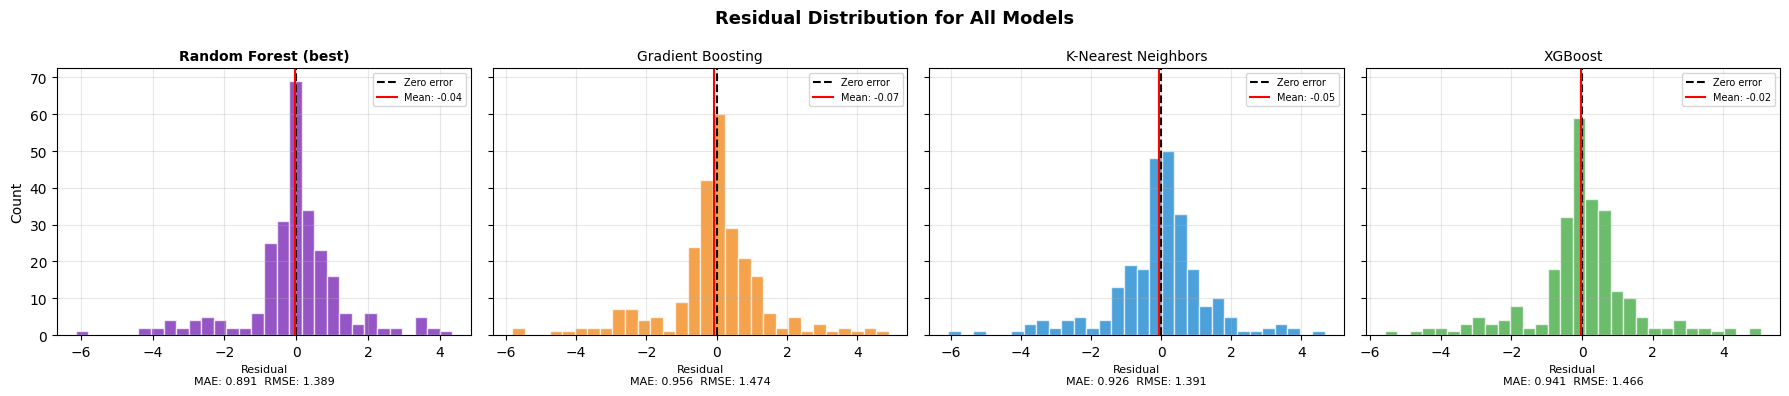

In [9]:
fig, axes = plt.subplots(1, len(model_names), figsize=(18, 4), sharey=True)
fig.suptitle("Residual Distribution for All Models", fontsize=13, fontweight='bold')

for ax, name in zip(axes, model_names):
    res = results[name]
    residuals = y_test.values - res["y_test_pred"]
    
    # Plot histogram
    ax.hist(residuals, bins=30, color=COLORS[name], alpha=0.7, edgecolor='white')
    
    # Add vertical lines
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Zero error')
    ax.axvline(residuals.mean(), color='red', linestyle='-', linewidth=1.5,
               label=f'Mean: {residuals.mean():.2f}')
    
    # Title & labels
    title = f"{name}" + (" (best)" if name == best_name else "")
    ax.set_title(title, fontsize=10, fontweight='bold' if name == best_name else 'normal')
    ax.set_xlabel(f"Residual\nMAE: {res['test_mae']:.3f}  RMSE: {res['test_rmse']:.3f}", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

#### Step 7B: Sorted actual vs predicted

Both series are independently sorted and overlaid. The shaded error band shows the gap between actual and predicted scores across the full range.


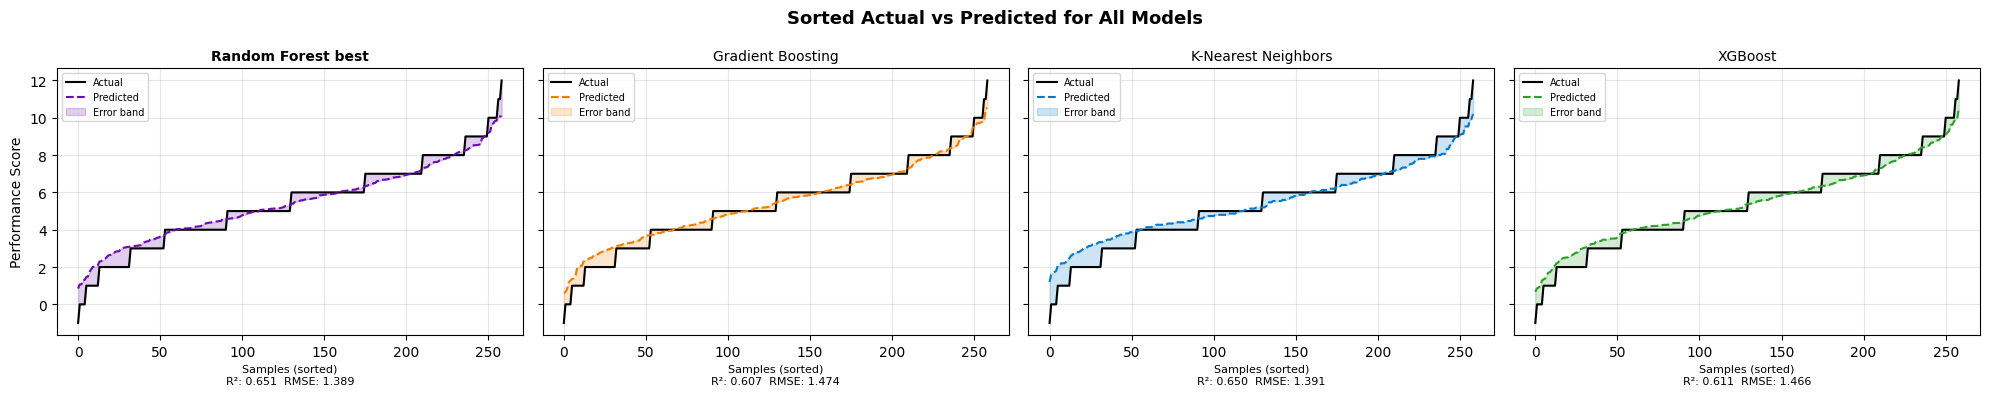

In [10]:
fig, axes = plt.subplots(1, len(model_names), figsize=(20, 4), sharey=True)
fig.suptitle("Sorted Actual vs Predicted for All Models", fontsize=13, fontweight='bold')

y_true_sorted = np.sort(y_test.values)

for ax, name in zip(axes, model_names):
    res           = results[name]
    color         = COLORS[name]
    y_pred_sorted = np.sort(res["y_test_pred"])
    n             = len(y_true_sorted)

    ax.plot(y_true_sorted, color='black', linewidth=1.5, label='Actual')
    ax.plot(y_pred_sorted, color=color,   linewidth=1.5, linestyle='--', label='Predicted')
    ax.fill_between(range(n), y_true_sorted, y_pred_sorted, alpha=0.2, color=color, label='Error band')

    title = f"{name}" + (" best" if name == best_name else "")
    ax.set_title(title, fontsize=10, fontweight='bold' if name == best_name else 'normal')
    ax.set_xlabel(f"Samples (sorted)\nR²: {res['test_r2']:.3f}  RMSE: {res['test_rmse']:.3f}", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Performance Score")
plt.tight_layout()
plt.show()


#### Step 7C: Model comparison bar chart

Side-by-side MAE / RMSE / R² bars for all four models. The best model bar is outlined in black.


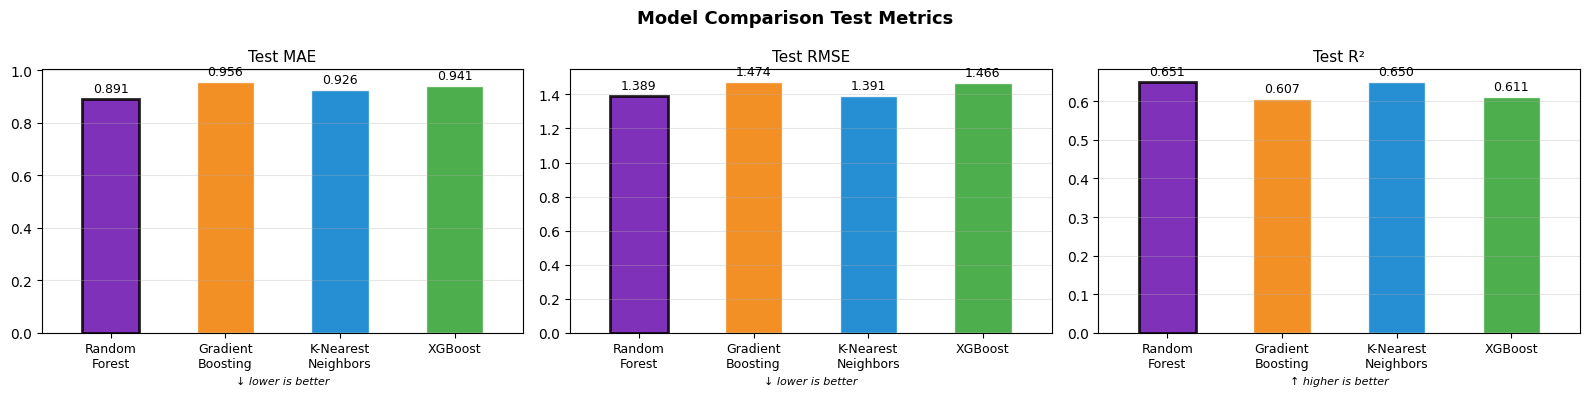

In [11]:
mae_values  = [results[n]["test_mae"]  for n in model_names]
rmse_values = [results[n]["test_rmse"] for n in model_names]
r2_values   = [results[n]["test_r2"]   for n in model_names]
bar_colors  = [COLORS[n] for n in model_names]
x           = np.arange(len(model_names))
best_idx    = model_names.index(best_name)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Model Comparison Test Metrics", fontsize=13, fontweight='bold')

for ax, title, values, note in zip(
    axes,
    ["Test MAE", "Test RMSE", "Test R²"],
    [mae_values, rmse_values, r2_values],
    ["↓ lower is better", "↓ lower is better", "↑ higher is better"],
):
    bars = ax.bar(x, values, width=0.5, color=bar_colors, alpha=0.85, edgecolor='white')
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_xlim(-0.6, len(model_names) - 0.4)
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace(" ", "\n") for n in model_names], fontsize=9)
    ax.set_xlabel(note, fontsize=8, style='italic')
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Step 8: Export the best model

Three artefacts are saved to `models/`:
- **`.joblib`** : the fitted estimator
- **`_meta.json`** : model name, feature list, target, and test metrics
- **`_encoders.joblib`** : fitted `LabelEncoder` instances for `agent` and `role`


In [12]:
import joblib
import json

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

model_path = MODELS_DIR / "valorant_performance_predictor.joblib"
joblib.dump(best_res["model"], model_path)

meta = {
    "model_name": best_name,
    "features":   FEATURES,
    "cat_cols":   cat_cols,
    "target":     TARGET,
    "test_mae":   round(best_res["test_mae"],  4),
    "test_rmse":  round(best_res["test_rmse"], 4),
    "test_r2":    round(best_res["test_r2"],   4),
}
with open(MODELS_DIR / "valorant_performance_predictor_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

joblib.dump(label_encoders, MODELS_DIR / "valorant_performance_predictor_encoders.joblib")

print(f"Model saved : {model_path}")
print(f"Metadata    : {MODELS_DIR / 'valorant_performance_predictor_meta.json'}")
print(f"Encoders    : {MODELS_DIR / 'valorant_performance_predictor_encoders.joblib'}")
print(json.dumps(meta, indent=2))


Model saved : C:\Personel\Github\Valorant_Player_Performance_Predictor\models\valorant_performance_predictor.joblib
Metadata    : C:\Personel\Github\Valorant_Player_Performance_Predictor\models\valorant_performance_predictor_meta.json
Encoders    : C:\Personel\Github\Valorant_Player_Performance_Predictor\models\valorant_performance_predictor_encoders.joblib
{
  "model_name": "Random Forest",
  "features": [
    "agent",
    "role",
    "avg_dmg_delta",
    "win_loss_margin",
    "kills",
    "deaths"
  ],
  "cat_cols": [
    "agent",
    "role"
  ],
  "target": "performance",
  "test_mae": 0.8913,
  "test_rmse": 1.3888,
  "test_r2": 0.6507
}
